# 01 - Train each model

Build and train every architecture through the `flashdet` library. This mirrors
what `train.py` does, but inline so you can watch the metrics. Use a small
dataset / few epochs here; for real runs use `python train.py --config ...`.

In [1]:
import sys
sys.path.append('..')

import torch
from flashdet import engine
from flashdet.data import make_train_val_loaders
from flashdet.models import build_model, MODEL_REGISTRY
from flashdet.utils import build_optimizer, build_scheduler, set_seed

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('available models:', list(MODEL_REGISTRY))

available models: ['unet', 'transformer', 'conformer', 'conformer_v2']


## Smoke test: the from-scratch conformer
Forward a dummy batch through `ConformerModel` and `ConformerModelv2` to confirm the
new `ConformerEncoder` (no `torchaudio`) wires up and returns per-bin outputs of the
right shape. Runs without any dataset.

In [2]:
from flashdet.models import build_model

window_len = 8000
dummy = torch.randn(2, 1, window_len, device=device)   # [B, 1, L]
for name in ('conformer', 'conformer_v2'):
    m = build_model(name, d_model=32, num_heads=4, num_layers=2).to(device).eval()
    with torch.no_grad():
        class_logits, reg_logits = m(dummy)
    assert class_logits.shape == (2, 1, window_len), class_logits.shape
    assert reg_logits.shape == (2, 1, window_len), reg_logits.shape
    print(f'{name:13s} OK  class={tuple(class_logits.shape)}  reg={tuple(reg_logits.shape)}')
print('conformer smoke test passed')

conformer     OK  class=(2, 1, 8000)  reg=(2, 1, 8000)
conformer_v2  OK  class=(2, 1, 8000)  reg=(2, 1, 8000)
conformer smoke test passed


/opt/conda/lib/python3.8/site-packages/torch/nn/functional.py:3631: UserWarning: Default upsampling behavior when mode=linear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  warnings.warn(


## Data
Point this at a dataset from notebook 00 (or a cluster path). The conformer and
transformer expect `window_len`-length waveforms (8000 by default); the U-Net
handles any length.

In [3]:
DATA_PATH = 'demo_dataset.npy'  # from notebook 00, or a real cluster .npy path
train_loader, val_loader, _ = make_train_val_loaders(
    DATA_PATH, batch_size=5, val_ratio=0.2)
print(len(train_loader), 'train batches')

32 train batches


## Build and train one model
Swap `name` for `'unet'`, `'transformer'`, `'conformer'`, or `'conformer_v2'`.
Constructor args match each model's signature (and the `configs/*.yaml` files).

In [8]:
model = build_model('conformer', d_model=64, num_heads=4, num_layers=2).to(device)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

optimizer = build_optimizer(model, {'lr': 1e-4})
scheduler = build_scheduler(optimizer, {'factor': 0.5, 'patience': 2})

results = engine.train(
    model, train_loader, val_loader, optimizer, scheduler,
    device=device, epochs=10, mode='mined_bce', val_every=5, save_every=999)

428,290 parameters


## Loss / accuracy curves

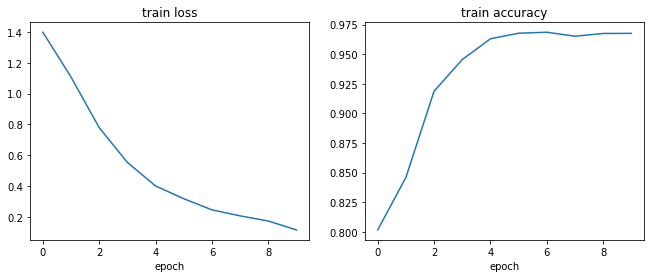

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(results['train_loss']); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(results['train_acc']); ax[1].set_title('train accuracy'); ax[1].set_xlabel('epoch')
plt.show()

## Train all four architectures
A quick loop to confirm each one builds, runs a forward/backward pass, and trains.
Sizes are tiny here just to keep it fast.

In [7]:
configs = {
    'unet':         dict(base_channels=8, depth=3),
    'transformer':  dict(d_model=32, num_heads=4, num_layers=2),
    'conformer':    dict(d_model=32, num_heads=4, num_layers=2),
    'conformer_v2': dict(d_model=32, num_heads=4, num_layers=2),
}
for name, args in configs.items():
    m = build_model(name, **args).to(device)
    opt = build_optimizer(m, {'lr': 1e-4})
    sch = build_scheduler(opt, {})
    r = engine.train(m, train_loader, val_loader, opt, sch,
                     device=device, epochs=10, val_every=99, save_every=99)
    print(f'{name:13s} final train loss = {r["train_loss"][-1]:.4f}')

unet          final train loss = 0.9260


transformer   final train loss = 0.6354


conformer     final train loss = 0.3914


conformer_v2  final train loss = 0.2384
